In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [2]:
df = pd.read_excel('Spam_Email_Classification_Dataset.csv')
df.head()

,EmailLength,NumLinks,ContainsOffer,Spam
0,61,3,1,1
1,103,2,1,1
2,88,2,1,1
3,94,2,1,1
4,24,2,1,1


In [3]:
df.info()
print(df['Spam'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   EmailLength    80 non-null     int64
 1   NumLinks       80 non-null     int64
 2   ContainsOffer  80 non-null     int64
 3   Spam           80 non-null     int64
dtypes: int64(4)
memory usage: 2.6 KB
Spam
1    40
0    40
Name: count, dtype: int64


In [4]:
X = df[['EmailLength', 'NumLinks', 'ContainsOffer']]
y = df['Spam']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [5]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")
print(classification_report(y_test, y_pred))

Accuracy: 100.00%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00        11

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16



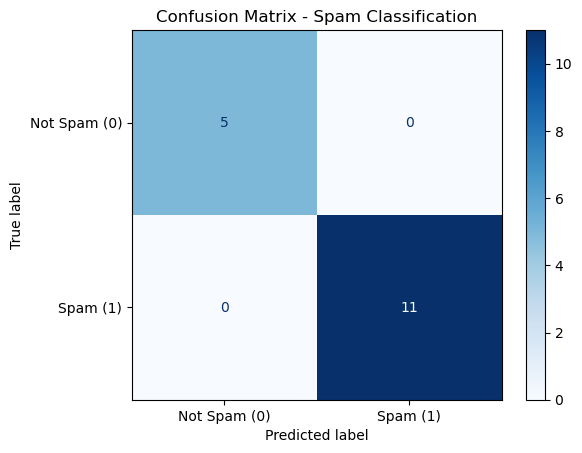

In [6]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Spam (0)', 'Spam (1)'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Spam Classification')
plt.show()

In [7]:
new_email = pd.DataFrame({
    'EmailLength': [85],
    'NumLinks': [2],
    'ContainsOffer': [1]
})

prediction = model.predict(new_email)[0]
probability = model.predict_proba(new_email)[0][1]

print(f"Prediction: {'Spam' if prediction == 1 else 'Not Spam'}")
print(f"Probability: {probability * 100:.2f}%")

Prediction: Spam
Probability: 89.38%
